In [ ]:
!pip install -q albumentations torchmetrics pytorch-lightning clearml python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.8 MB/s eta 0:00:00


In [ ]:
import os
import math
import shutil
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A
import pytorch_lightning as pl
from pytorch_lightning.callbacks import Callback, TQDMProgressBar
from torch.utils.data import DataLoader, Dataset
from torchmetrics import JaccardIndex
from albumentations.pytorch import ToTensorV2
from clearml import Task
import cv2
import numpy as np
from google.colab import files
from dotenv import load_dotenv

In [ ]:
from google.colab import userdata, drive

os.environ['CLEARML_API_ACCESS_KEY'] = userdata.get('CLEARML_API_ACCESS_KEY')
os.environ['CLEARML_API_SECRET_KEY'] = userdata.get('CLEARML_API_SECRET_KEY')

In [ ]:
drive.mount('/content/drive')


source_path = '/content/drive/MyDrive/'

tasks = [
    {
        "files": ["leftImg8bit_trainvaltest.zip", "gtFine_trainvaltest.zip"],
        "dest": "/content/data/cityscapes/"
    }
]

for task in tasks:
    if not os.path.exists(task["dest"]):
        os.makedirs(task["dest"])

    for zip_file in task["files"]:
        full_path = os.path.join(source_path, zip_file)

        if os.path.exists(full_path):
            print(f"Unpacking {zip_file} in {task['dest']}...")
            !unzip -q -o "{full_path}" -d "{task['dest']}"
        else:
            print(f"Error, file not found: {full_path}")

Mounted at /content/drive
Unpacking leftImg8bit_trainvaltest.zip in /content/data/cityscapes/...
Unpacking gtFine_trainvaltest.zip in /content/data/cityscapes/...


In [ ]:
CONFIG = {
    "project_name": "Segmentation_Urban_Scene_CourseWork",
    "task_name": "DinoV2_Small_Cityscapes_E4_SourceConsistency",
    "data_dir": "./data/cityscapes",
    "model_name": "dinov2_vits14",
    "classes": 19,
    "batch_size": 16,
    "lr": 1.5e-4,
    "weight_decay": 0.05,
    "epochs": 24,
    "image_size": (518, 1022),
    "freeze_backbone": False,
    "num_workers": 4,
    "check_val_every_n_epoch": 2,
    "early_stopping_patience": 4,
    "early_stopping_min_delta": 0.001,
    "consistency_weight": 0.15,
    "consistency_confidence_threshold": 0.80,
    "consistency_rampup_epochs": 4,
    "consistency_every_n_steps": 2,
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

torch.set_float32_matmul_precision('medium')
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

task = Task.init(
    project_name=CONFIG["project_name"],
    task_name=CONFIG["task_name"],
    output_uri=False
)
task.connect(CONFIG)


ClearML Task: created new task id=d6d1db83611b49329e918677328df612


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


ClearML results page: https://app.clear.ml/projects/588d5d925230490b9f98b1007b4c7fa0/experiments/d6d1db83611b49329e918677328df612/output/log


{'project_name': 'Segmentation_Urban_Scene_CourseWork',
 'task_name': 'DinoV2_Small_Cityscapes_E4_SourceConsistency',
 'data_dir': './data/cityscapes',
 'model_name': 'dinov2_vits14',
 'classes': 19,
 'batch_size': 16,
 'lr': 0.00015,
 'weight_decay': 0.05,
 'epochs': 24,
 'image_size': (518, 1022),
 'freeze_backbone': False,
 'num_workers': 4,
 'check_val_every_n_epoch': 2,
 'early_stopping_patience': 4,
 'early_stopping_min_delta': 0.001,
 'consistency_weight': 0.15,
 'consistency_confidence_threshold': 0.8,
 'consistency_rampup_epochs': 4,
 'consistency_every_n_steps': 2,
 'device': 'cuda'}

In [ ]:
class CityscapesDataset(Dataset):
    def __init__(
        self,
        root_dir,
        split='train',
        base_augmentation=None,
        weak_image_augmentation=None,
        strong_image_augmentation=None,
        augmentation=None,
    ):
        self.root_dir = root_dir
        self.images_dir = os.path.join(root_dir, 'leftImg8bit', split)
        self.masks_dir = os.path.join(root_dir, 'gtFine', split)
        self.base_augmentation = base_augmentation
        self.weak_image_augmentation = weak_image_augmentation
        self.strong_image_augmentation = strong_image_augmentation
        self.augmentation = augmentation
        self.use_consistency_views = (
            split == 'train'
            and weak_image_augmentation is not None
            and strong_image_augmentation is not None
        )
        self.ids = []

        for city in os.listdir(self.images_dir):
            img_dir = os.path.join(self.images_dir, city)
            mask_dir = os.path.join(self.masks_dir, city)
            for file_name in os.listdir(img_dir):
                if file_name.endswith('_leftImg8bit.png'):
                   self.ids.append({
                       'image': os.path.join(img_dir, file_name),
                       'mask': os.path.join(mask_dir, file_name.replace('_leftImg8bit.png', '_gtFine_labelIds.png'))
                   })

        self.mapping = {
            7: 0, 8: 1, 11: 2, 12: 3, 13: 4, 17: 5, 19: 6, 20: 7, 21: 8, 22: 9,
            23: 10, 24: 11, 25: 12, 26: 13, 27: 14, 28: 15, 31: 16, 32: 17, 33: 18
        }

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        sample = self.ids[i]
        image = cv2.imread(sample['image'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(sample['mask'], 0)

        mask_mapped = np.ones_like(mask) * 255
        for k, v in self.mapping.items():
            mask_mapped[mask == k] = v
        mask = mask_mapped

        if self.base_augmentation:
            sample = self.base_augmentation(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']

        if self.use_consistency_views:
            weak_image = self.weak_image_augmentation(image=image)['image']
            strong = self.strong_image_augmentation(image=image, mask=mask)
            strong_image, mask = strong['image'], strong['mask']
            return weak_image, strong_image, mask.long()

        if self.augmentation:
            sample = self.augmentation(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']

        return image, mask.long()


In [ ]:
class RoadDataModule(pl.LightningDataModule):
  def __init__(self, data_dir, batch_size, image_size, num_workers):
      super().__init__()
      self.data_dir = data_dir
      self.batch_size = batch_size
      self.image_size = image_size
      self.num_workers = num_workers

  def setup(self, stage=None):
      self.shared_train_transform = A.Compose([
          A.Resize(height=self.image_size[0], width=self.image_size[1]),
          A.HorizontalFlip(p=0.5),
      ])

      self.weak_image_transform = A.Compose([
          A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
          ToTensorV2(),
      ])

      self.strong_image_transform = A.Compose([
          A.OneOf([
              A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),
              A.RandomGamma(gamma_limit=(70, 120), p=1.0),
              A.RandomBrightnessContrast(brightness_limit=0.35, contrast_limit=0.35, p=1.0),
              A.RandomShadow(p=1.0),
          ], p=0.75),
          A.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.2, hue=0.08, p=0.4),
          A.OneOf([
              A.RandomFog(p=1.0),
              A.RandomRain(blur_value=3, brightness_coefficient=0.9, p=1.0),
              A.RandomSnow(p=1.0),
          ], p=0.30),
          A.OneOf([
              A.GaussNoise(p=1.0),
              A.GaussianBlur(blur_limit=(3, 7), p=1.0),
              A.MotionBlur(blur_limit=5, p=1.0),
          ], p=0.20),
          A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
          ToTensorV2(),
      ])

      self.valid_transform = A.Compose([
          A.Resize(height=self.image_size[0], width=self.image_size[1]),
          A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
          ToTensorV2(),
      ])

      self.train_ds = CityscapesDataset(
          self.data_dir,
          split='train',
          base_augmentation=self.shared_train_transform,
          weak_image_augmentation=self.weak_image_transform,
          strong_image_augmentation=self.strong_image_transform,
      )
      self.val_ds = CityscapesDataset(
          self.data_dir,
          split='val',
          augmentation=self.valid_transform,
      )

  def train_dataloader(self):
      return DataLoader(
          self.train_ds,
          batch_size=self.batch_size,
          shuffle=True,
          num_workers=self.num_workers,
          pin_memory=True,
          persistent_workers=self.num_workers > 0,
      )

  def val_dataloader(self):
      return DataLoader(
          self.val_ds,
          batch_size=self.batch_size,
          shuffle=False,
          num_workers=self.num_workers,
          pin_memory=True,
          persistent_workers=self.num_workers > 0,
      )


In [ ]:
class LinearSegmentationHead(nn.Module):
    def __init__(self, embed_dim=384, num_classes=19, patch_size=14):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_classes = num_classes
        self.patch_size = patch_size
        self.linear = nn.Conv2d(embed_dim, num_classes, kernel_size=1)

    def forward(self, x, h, w):
        B, N, C = x.shape
        patch_h = h // self.patch_size
        patch_w = w // self.patch_size
        x = x.reshape(B, patch_h, patch_w, C).permute(0, 3, 1, 2)
        x = self.linear(x)
        x = F.interpolate(x, size=(h, w), mode='bilinear', align_corners=False)
        return x


class ClearMLMetricsCallback(Callback):
    def __init__(self, task):
        super().__init__()
        self._logger = task.get_logger()

    def _log_metrics(self, trainer, stage):
        for name, value in trainer.callback_metrics.items():
            if isinstance(value, torch.Tensor):
                value = value.detach().cpu().item()
            if isinstance(value, (int, float)) and math.isfinite(value):
                self._logger.report_scalar(stage, name, value, iteration=trainer.current_epoch)

    def on_train_epoch_end(self, trainer, pl_module):
        self._log_metrics(trainer, "train")

    def on_validation_epoch_end(self, trainer, pl_module):
        self._log_metrics(trainer, "val")


class RoadModel(pl.LightningModule):
    def __init__(
        self,
        model_name='dinov2_vits14',
        num_classes=19,
        lr=1e-4,
        weight_decay=0.05,
        epochs=24,
        freeze_backbone=True,
        consistency_weight=0.15,
        consistency_confidence_threshold=0.80,
        consistency_rampup_epochs=4,
        consistency_every_n_steps=2,
    ):
        super().__init__()
        self.save_hyperparameters()

        self.backbone = torch.hub.load('facebookresearch/dinov2', model_name)
        self.embed_dim = 384
        self.patch_size = 14

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            print("Backbone frozen!")

        self.segmentation_head = LinearSegmentationHead(
            embed_dim=self.embed_dim,
            num_classes=num_classes,
            patch_size=self.patch_size
        )

        self.criterion = nn.CrossEntropyLoss(ignore_index=255)
        self.train_miou = JaccardIndex(task="multiclass", num_classes=num_classes, ignore_index=255)
        self.val_miou = JaccardIndex(task="multiclass", num_classes=num_classes, ignore_index=255)

    def forward(self, x):
        B, C, H, W = x.shape
        features = self.backbone.forward_features(x)
        patch_features = features['x_norm_patchtokens']
        logits = self.segmentation_head(patch_features, H, W)
        return logits

    def _consistency_scale(self):
        rampup_epochs = max(1, self.hparams.consistency_rampup_epochs)
        return min(1.0, float(self.current_epoch + 1) / float(rampup_epochs))

    def training_step(self, batch, batch_idx):
        images_weak, images_strong, masks = batch
        strong_logits = self(images_strong)
        supervised_loss = self.criterion(strong_logits, masks)

        apply_consistency = (batch_idx % self.hparams.consistency_every_n_steps) == 0
        consistency_loss = torch.tensor(0.0, device=self.device)
        confident_ratio = torch.tensor(0.0, device=self.device)

        if apply_consistency:
            with torch.no_grad():
                weak_logits = self(images_weak)
                weak_probs = torch.softmax(weak_logits, dim=1)
                weak_confidence, weak_pseudo = weak_probs.max(dim=1)

            consistency_mask = (weak_confidence >= self.hparams.consistency_confidence_threshold) & (masks != 255)
            confident_ratio = consistency_mask.float().mean()

            if consistency_mask.any():
                pseudo_targets = weak_pseudo.clone()
                pseudo_targets[~consistency_mask] = 255
                consistency_loss = self.criterion(strong_logits, pseudo_targets)

        consistency_scale = self._consistency_scale() * self.hparams.consistency_weight
        loss = supervised_loss + consistency_scale * consistency_loss

        preds = torch.argmax(strong_logits, dim=1)
        miou = self.train_miou(preds, masks)

        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        self.log("train_supervised_loss", supervised_loss, on_step=False, on_epoch=True, logger=True)
        self.log("train_consistency_loss", consistency_loss, on_step=False, on_epoch=True, logger=True)
        self.log("train_consistency_scale", consistency_scale, on_step=False, on_epoch=True, logger=True)
        self.log("train_consistency_keep_ratio", confident_ratio, on_step=False, on_epoch=True, logger=True)
        self.log("train_miou", miou, on_step=False, on_epoch=True, prog_bar=True, logger=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, masks = batch
        logits = self(images)
        loss = self.criterion(logits, masks)
        preds = torch.argmax(logits, dim=1)
        miou = self.val_miou(preds, masks)

        self.log("val_loss", loss, on_epoch=True, prog_bar=True, logger=True)
        self.log("val_miou", miou, on_epoch=True, prog_bar=True, logger=True)
        return loss

    def configure_optimizers(self):
        if self.hparams.freeze_backbone:
            params = self.segmentation_head.parameters()
        else:
            params = [
                {"params": self.segmentation_head.parameters(), "lr": self.hparams.lr},
                {"params": self.backbone.parameters(), "lr": self.hparams.lr * 0.1}
            ]

        optimizer = torch.optim.AdamW(
            params,
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay,
            betas=(0.9, 0.999),
            eps=1e-8
        )

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=self.hparams.epochs,
            eta_min=1e-6
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "epoch"
            }
        }


In [ ]:
dm = RoadDataModule(
    CONFIG["data_dir"],
    CONFIG["batch_size"],
    CONFIG["image_size"],
    CONFIG["num_workers"]
)

model = RoadModel(
    model_name=CONFIG["model_name"],
    num_classes=CONFIG["classes"],
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
    epochs=CONFIG["epochs"],
    freeze_backbone=CONFIG["freeze_backbone"],
    consistency_weight=CONFIG["consistency_weight"],
    consistency_confidence_threshold=CONFIG["consistency_confidence_threshold"],
    consistency_rampup_epochs=CONFIG["consistency_rampup_epochs"],
    consistency_every_n_steps=CONFIG["consistency_every_n_steps"]
)

checkpoint_callback = pl.callbacks.ModelCheckpoint(
    monitor="val_miou",
    dirpath="./checkpoints",
    filename="dinov2-small-E4-cityscapes-{epoch:02d}-{val_miou:.4f}",
    save_top_k=1,
    mode="max",
)

early_stopping = pl.callbacks.EarlyStopping(
    monitor="val_miou",
    patience=CONFIG["early_stopping_patience"],
    min_delta=CONFIG["early_stopping_min_delta"],
    mode="max",
)

trainer = pl.Trainer(
    max_epochs=CONFIG["epochs"],
    accelerator="gpu",
    devices=1,
    logger=True,
    callbacks=[
        checkpoint_callback,
        early_stopping,
        TQDMProgressBar(refresh_rate=20),
        ClearMLMetricsCallback(task)
    ],
    precision="16-mixed",
    accumulate_grad_batches=4,
    check_val_every_n_epoch=CONFIG["check_val_every_n_epoch"]
)

trainer.fit(model, datamodule=dm)


Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning:

xFormers is not available (SwiGLU)

/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning:

xFormers is not available (Attention)

/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning:

xFormers is not available (Block)



Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 307MB/s]
INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: UserWarning:

Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.



┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name              ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone          │ DinoVisionTransformer  │ 22.1 M │ train │     0 │
│ 1 │ segmentation_head │ LinearSegmentationHead │  7.3 K │ train │     0 │
│ 2 │ criterion         │ CrossEntropyLoss       │      0 │ train │     0 │
│ 3 │ train_miou        │ MulticlassJaccardIndex │      0 │ train │     0 │
│ 4 │ val_miou          │ MulticlassJaccardIndex │      0 │ train │     0 │
└───┴───────────────────┴────────────────────────┴────────┴───────┴───────┘

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=24` reached.


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
Connecting multiple input models with the same name: `dinov2_vits14_pretrain`. This might result in the wrong model being used when executing remotely
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         val_loss          │    0.16543719172477722    │
│         val_miou          │    0.6218311190605164     │
└───────────────────────────┴───────────────────────────┘


Results:



,Metric,Value
0,Loss,0.1654
1,mIoU,0.6218
2,Percent,62.18%


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning:

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.



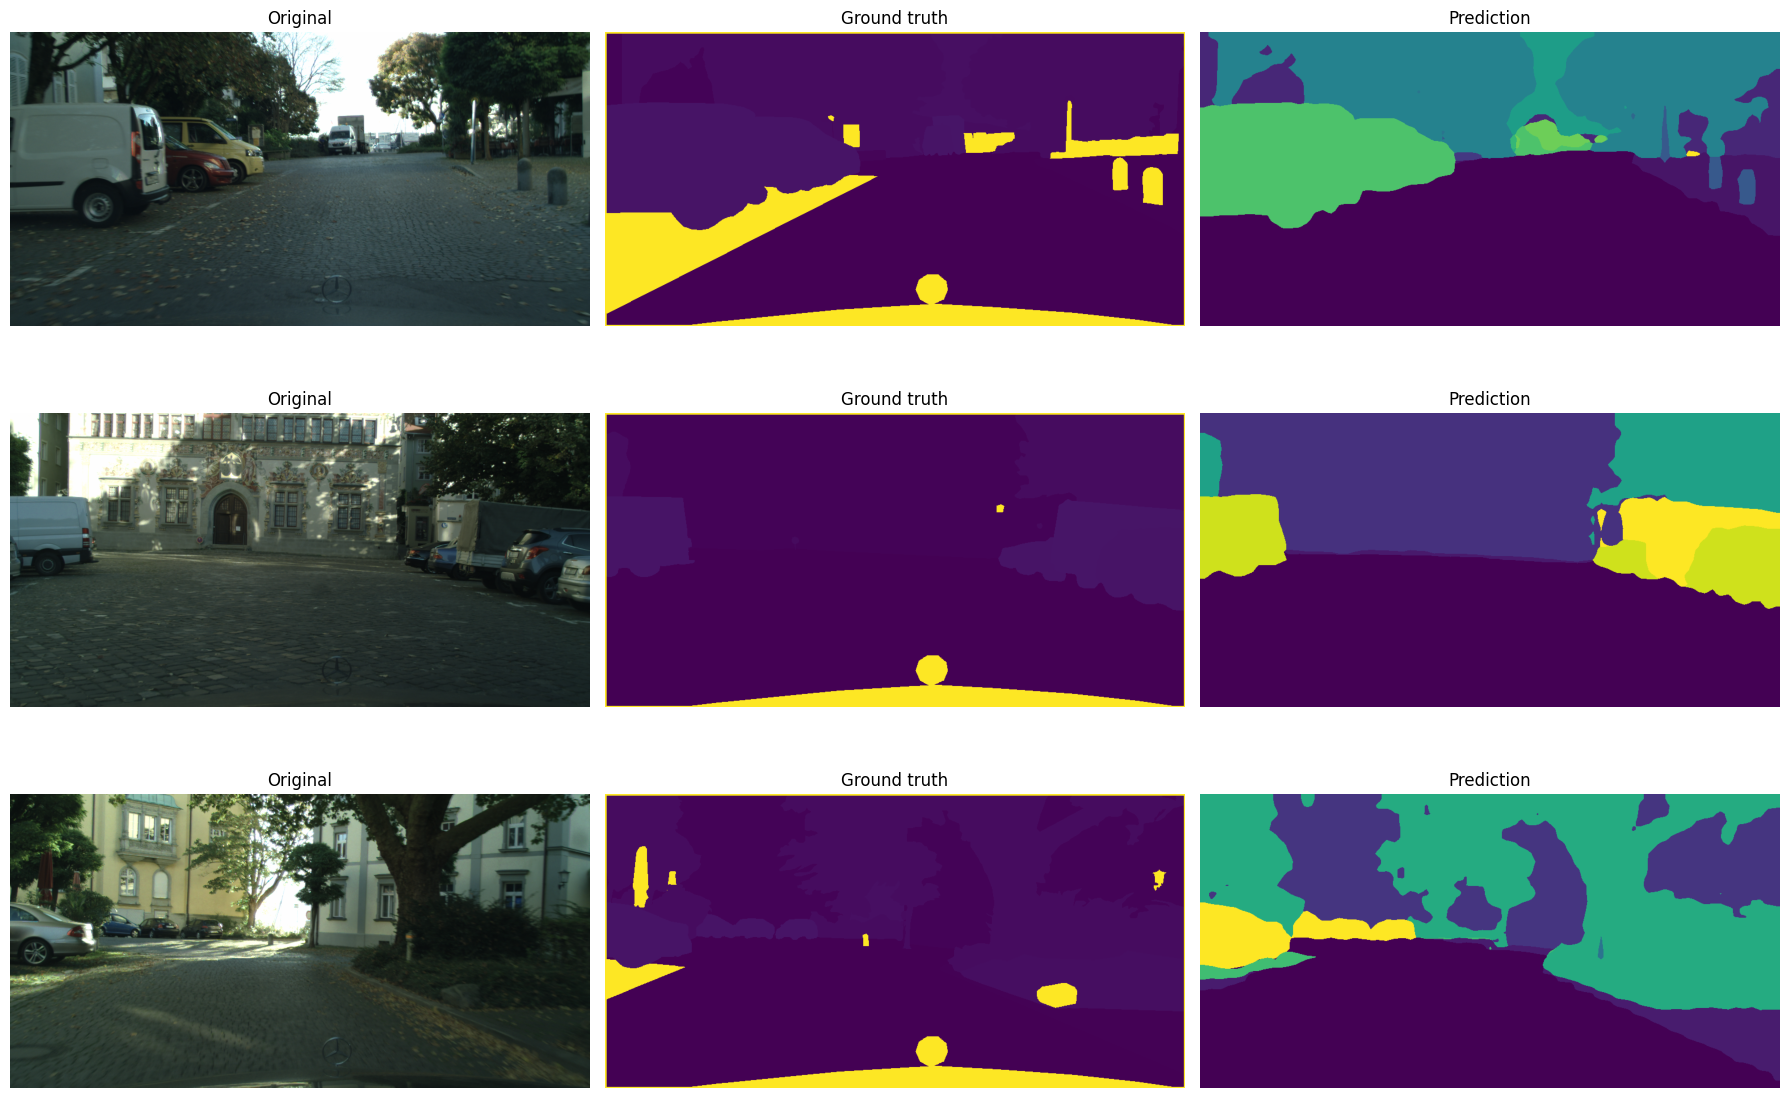

In [ ]:
best_model_path = trainer.checkpoint_callback.best_model_path

best_model = RoadModel.load_from_checkpoint(best_model_path)
best_model.to(CONFIG["device"])
best_model.eval()

# Validate the best model
val_results = trainer.validate(best_model, datamodule=dm)[0]

metrics_data = {
    "Metric": ["Loss", "mIoU", "Percent"],
    "Value": [
        f"{val_results['val_loss']:.4f}",
        f"{val_results['val_miou']:.4f}",
        f"{val_results['val_miou']*100:.2f}%"
    ]
}
df = pd.DataFrame(metrics_data)

print("\n" + "="*30)
print("Results:" + "\n")
print("="*30)
display(df)

def visualize_predictions(model, datamodule, num_samples=3):
    model.to(CONFIG["device"])
    model.eval()

    val_loader = datamodule.val_dataloader()
    images, masks = next(iter(val_loader))

    images = images.to(CONFIG["device"])
    with torch.no_grad():
        logits = model(images)
        preds = torch.argmax(logits, dim=1)

    images = images.cpu()
    masks = masks.cpu()
    preds = preds.cpu()

    plt.figure(figsize=(18, num_samples * 4))

    for i in range(min(num_samples, len(images))):
        # Denormalize image for visualization
        img = images[i].permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(img)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(masks[i])
        plt.title("Ground truth")
        plt.axis("off")

        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(preds[i])
        plt.title(f"Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

visualize_predictions(best_model, dm)

In [ ]:
best_model_path = trainer.checkpoint_callback.best_model_path

model_name = os.path.basename(best_model_path)

current_task = Task.get_task(task_id=task.id)

current_task.update_output_model(
    model_path=best_model_path,
    model_name=model_name,
    iteration=trainer.current_epoch
)

'https://files.clear.ml/Segmentation_Urban_Scene_CourseWork/DinoV2_Small_Cityscapes_E4_SourceConsistency.d6d1db83611b49329e918677328df612/models/dinov2-small-E4-cityscapes-epoch=23-val_miou=0.6218.ckpt'

In [ ]:
task.close()

In [ ]:
from google.colab import runtime
runtime.unassign()